In [1]:
import numpy as np
import pandas as pd
import joblib
import time

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
X_train = joblib.load("../data/X_train_zero_day.pkl")
y_train = joblib.load("../data/y_train_zero_day.pkl")

X_test_seen = joblib.load("../data/X_test_seen.pkl")
y_test_seen = joblib.load("../data/y_test_seen.pkl")

X_test_zero_day = joblib.load("../data/X_test_zero_day.pkl")
y_test_zero_day = joblib.load("../data/y_test_zero_day.pkl")

X_train_scaled = joblib.load("../data/X_train_zero_day_scaled.pkl")

X_test_seen_scaled = joblib.load("../data/X_test_seen_scaled.pkl")

X_test_zero_day_scaled = joblib.load("../data/X_test_zero_day_scaled.pkl")

print("Train:", X_train.shape)
print("Seen Test:", X_test_seen.shape)
print("Zero-Day Test:", X_test_zero_day.shape)

Train: (125973, 122)
Seen Test: (18794, 122)
Zero-Day Test: (3750, 122)


In [3]:
X_train_model, X_val, y_train_model, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=42
)

print("Training:", X_train_model.shape)
print("Validation:", X_val.shape)

print("\nTraining class distribution:")
print(pd.Series(y_train_model).value_counts())

print("\nValidation class distribution:")
print(pd.Series(y_val).value_counts())

Training: (100778, 122)
Validation: (25195, 122)

Training class distribution:
binary_label
0    53874
1    46904
Name: count, dtype: int64

Validation class distribution:
binary_label
0    13469
1    11726
Name: count, dtype: int64


In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

In [5]:
def evaluate_zero_day_model(
    model,
    X_train,
    y_train,
    X_test_seen,
    y_test_seen,
    X_test_zero_day,
    y_test_zero_day
):
    
    print("=" * 60)
    print(f"Model: {model.__class__.__name__}")
    print("=" * 60)

    # -------------------------
    # Training
    # -------------------------
    start_train = time.time()

    model.fit(X_train, y_train)

    train_time = time.time() - start_train

    # -------------------------
    # Prediction - Seen Test
    # -------------------------
    start_predict_seen = time.time()

    y_pred_seen = model.predict(X_test_seen)

    predict_seen_time = time.time() - start_predict_seen

    # -------------------------
    # Prediction - Zero-Day
    # -------------------------
    start_predict_zero = time.time()

    y_pred_zero_day = model.predict(X_test_zero_day)

    predict_zero_day_time = time.time() - start_predict_zero

    # -------------------------
    # Normal Test Metrics
    # -------------------------
    accuracy = accuracy_score(
        y_test_seen,
        y_pred_seen
    )

    precision = precision_score(
        y_test_seen,
        y_pred_seen
    )

    recall = recall_score(
        y_test_seen,
        y_pred_seen
    )

    f1 = f1_score(
        y_test_seen,
        y_pred_seen
    )

    # -------------------------
    # Zero-Day Detection Rate
    # -------------------------
    zero_day_detection_rate = np.mean(
        y_pred_zero_day == 1
    )

    print("\n--- Seen Test Performance ---")

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")

    print("\n--- Zero-Day Performance ---")

    print(
        f"Zero-Day Detection Rate: "
        f"{zero_day_detection_rate:.4f}"
    )

    print(
        f"Zero-Day Detection Rate: "
        f"{zero_day_detection_rate * 100:.2f}%"
    )

    print("\n--- Time ---")

    print(
        f"Training Time: "
        f"{train_time:.4f} seconds"
    )

    print(
        f"Seen Prediction Time: "
        f"{predict_seen_time:.4f} seconds"
    )

    print(
        f"Zero-Day Prediction Time: "
        f"{predict_zero_day_time:.4f} seconds"
    )

    return {
        "model": model.__class__.__name__,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "zero_day_detection_rate":
            zero_day_detection_rate,
        "train_time": train_time,
        "predict_seen_time":
            predict_seen_time,
        "predict_zero_day_time":
            predict_zero_day_time
    }

In [6]:
knn = KNeighborsClassifier(
    n_neighbors=5,
    n_jobs=-1
)

knn_result = evaluate_zero_day_model(
    knn,
    X_train_scaled,
    y_train,
    X_test_seen_scaled,
    y_test_seen,
    X_test_zero_day_scaled,
    y_test_zero_day
)

Model: KNeighborsClassifier

--- Seen Test Performance ---
Accuracy : 0.8373
Precision: 0.9065
Recall   : 0.7397
F1-Score : 0.8147

--- Zero-Day Performance ---
Zero-Day Detection Rate: 0.4352
Zero-Day Detection Rate: 43.52%

--- Time ---
Training Time: 0.0387 seconds
Seen Prediction Time: 22.7215 seconds
Zero-Day Prediction Time: 4.6081 seconds


In [7]:
svm = LinearSVC(
    random_state=42,
    max_iter=5000
)

svm_result = evaluate_zero_day_model(
    svm,
    X_train_scaled,
    y_train,
    X_test_seen_scaled,
    y_test_seen,
    X_test_zero_day_scaled,
    y_test_zero_day
)

Model: LinearSVC

--- Seen Test Performance ---
Accuracy : 0.8218
Precision: 0.8990
Recall   : 0.7111
F1-Score : 0.7941

--- Zero-Day Performance ---
Zero-Day Detection Rate: 0.3653
Zero-Day Detection Rate: 36.53%

--- Time ---
Training Time: 21.9475 seconds
Seen Prediction Time: 0.0066 seconds
Zero-Day Prediction Time: 0.0015 seconds


In [8]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

lr_result = evaluate_zero_day_model(
    lr,
    X_train_scaled,
    y_train,
    X_test_seen_scaled,
    y_test_seen,
    X_test_zero_day_scaled,
    y_test_zero_day
)

Model: LogisticRegression


c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



--- Seen Test Performance ---
Accuracy : 0.8226
Precision: 0.8997
Recall   : 0.7123
F1-Score : 0.7951

--- Zero-Day Performance ---
Zero-Day Detection Rate: 0.4064
Zero-Day Detection Rate: 40.64%

--- Time ---
Training Time: 6.3647 seconds
Seen Prediction Time: 0.0055 seconds
Zero-Day Prediction Time: 0.0022 seconds


تمرکز روی RF و DT

In [9]:
rf = RandomForestClassifier(
    n_estimators=250,
    max_depth=40,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train_model,
    y_train_model
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [10]:
val_scores = rf.predict_proba(X_val)[:, 1]

print("Validation scores generated.")
print("Min:", val_scores.min())
print("Max:", val_scores.max())
print("Mean:", val_scores.mean())

Validation scores generated.
Min: 0.0
Max: 1.0
Mean: 0.46573557451875375


In [11]:
thresholds = np.arange(
    0.05,
    0.96,
    0.01
)

results = []

for threshold in thresholds:

    y_pred = (
        val_scores >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        y_pred
    ).ravel()

    accuracy = accuracy_score(
        y_val,
        y_pred
    )

    precision = precision_score(
        y_val,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_pred,
        zero_division=0
    )

    fpr = fp / (fp + tn)

    results.append({
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "FPR": fpr,
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn
    })

rf_threshold_results = pd.DataFrame(results)

rf_threshold_results.head()

,Threshold,Accuracy,Precision,Recall,F1,FPR,TP,FP,TN,FN
0,0.05,0.995753,0.991207,0.999744,0.995457,0.007721,11723,104,13365,3
1,0.06,0.996150,0.992045,0.999744,0.995880,0.006979,11723,94,13375,3
2,0.07,0.996309,0.992381,0.999744,0.996049,0.006682,11723,90,13379,3
3,0.08,0.996468,0.992717,0.999744,0.996218,0.006385,11723,86,13383,3
4,0.09,0.996706,0.993222,0.999744,0.996472,0.005940,11723,80,13389,3


In [12]:
fpr_3 = rf_threshold_results[
    rf_threshold_results["FPR"] <= 0.03
].copy()

fpr_3.sort_values(
    "Recall",
    ascending=False
).head(10)

,Threshold,Accuracy,Precision,Recall,F1,FPR,TP,FP,TN,FN
0,0.05,0.995753,0.991207,0.999744,0.995457,0.007721,11723,104,13365,3
1,0.06,0.996150,0.992045,0.999744,0.995880,0.006979,11723,94,13375,3
2,0.07,0.996309,0.992381,0.999744,0.996049,0.006682,11723,90,13379,3
3,0.08,0.996468,0.992717,0.999744,0.996218,0.006385,11723,86,13383,3
4,0.09,0.996706,0.993222,0.999744,0.996472,0.005940,11723,80,13389,3
5,0.10,0.996864,0.993559,0.999744,0.996642,0.005643,11723,76,13393,3
6,0.11,0.997182,0.994233,0.999744,0.996981,0.005049,11723,68,13401,3
7,0.12,0.997500,0.994908,0.999744,0.997320,0.004455,11723,60,13409,3
8,0.13,0.997658,0.995246,0.999744,0.997490,0.004158,11723,56,13413,3
9,0.14,0.997777,0.995499,0.999744,0.997617,0.003935,11723,53,13416,3


In [13]:
fpr_5 = rf_threshold_results[
    rf_threshold_results["FPR"] <= 0.05
].copy()

fpr_5.sort_values(
    "Recall",
    ascending=False
).head(10)

,Threshold,Accuracy,Precision,Recall,F1,FPR,TP,FP,TN,FN
0,0.05,0.995753,0.991207,0.999744,0.995457,0.007721,11723,104,13365,3
1,0.06,0.996150,0.992045,0.999744,0.995880,0.006979,11723,94,13375,3
2,0.07,0.996309,0.992381,0.999744,0.996049,0.006682,11723,90,13379,3
3,0.08,0.996468,0.992717,0.999744,0.996218,0.006385,11723,86,13383,3
4,0.09,0.996706,0.993222,0.999744,0.996472,0.005940,11723,80,13389,3
5,0.10,0.996864,0.993559,0.999744,0.996642,0.005643,11723,76,13393,3
6,0.11,0.997182,0.994233,0.999744,0.996981,0.005049,11723,68,13401,3
7,0.12,0.997500,0.994908,0.999744,0.997320,0.004455,11723,60,13409,3
8,0.13,0.997658,0.995246,0.999744,0.997490,0.004158,11723,56,13413,3
9,0.14,0.997777,0.995499,0.999744,0.997617,0.003935,11723,53,13416,3


In [14]:
def best_threshold_under_fpr(
    results,
    max_fpr
):

    valid = results[
        results["FPR"] <= max_fpr
    ].copy()

    if len(valid) == 0:
        return None

    return (
        valid
        .sort_values(
            ["Recall", "F1"],
            ascending=False
        )
        .iloc[0]
    )

In [15]:
best_3 = best_threshold_under_fpr(
    rf_threshold_results,
    0.03
)

best_5 = best_threshold_under_fpr(
    rf_threshold_results,
    0.05
)

best_10 = best_threshold_under_fpr(
    rf_threshold_results,
    0.10
)

print("FPR <= 3%")
print(best_3)

print("\nFPR <= 5%")
print(best_5)

print("\nFPR <= 10%")
print(best_10)

FPR <= 3%
Threshold        0.190000
Accuracy         0.998412
Precision        0.996854
Recall           0.999744
F1               0.998297
FPR              0.002747
TP           11723.000000
FP              37.000000
TN           13432.000000
FN               3.000000
Name: 14, dtype: float64

FPR <= 5%
Threshold        0.190000
Accuracy         0.998412
Precision        0.996854
Recall           0.999744
F1               0.998297
FPR              0.002747
TP           11723.000000
FP              37.000000
TN           13432.000000
FN               3.000000
Name: 14, dtype: float64

FPR <= 10%
Threshold        0.190000
Accuracy         0.998412
Precision        0.996854
Recall           0.999744
F1               0.998297
FPR              0.002747
TP           11723.000000
FP              37.000000
TN           13432.000000
FN               3.000000
Name: 14, dtype: float64


In [16]:
print("Best threshold with FPR <= 3%:")
print(best_3)

print("\nBest threshold with FPR <= 5%:")
print(best_5)

print("\nBest threshold with FPR <= 10%:")
print(best_10)

Best threshold with FPR <= 3%:
Threshold        0.190000
Accuracy         0.998412
Precision        0.996854
Recall           0.999744
F1               0.998297
FPR              0.002747
TP           11723.000000
FP              37.000000
TN           13432.000000
FN               3.000000
Name: 14, dtype: float64

Best threshold with FPR <= 5%:
Threshold        0.190000
Accuracy         0.998412
Precision        0.996854
Recall           0.999744
F1               0.998297
FPR              0.002747
TP           11723.000000
FP              37.000000
TN           13432.000000
FN               3.000000
Name: 14, dtype: float64

Best threshold with FPR <= 10%:
Threshold        0.190000
Accuracy         0.998412
Precision        0.996854
Recall           0.999744
F1               0.998297
FPR              0.002747
TP           11723.000000
FP              37.000000
TN           13432.000000
FN               3.000000
Name: 14, dtype: float64


In [17]:
selected_threshold = best_5["Threshold"]

print(
    "Selected threshold:",
    selected_threshold
)

Selected threshold: 0.19


In [18]:
seen_scores = rf.predict_proba(
    X_test_seen
)[:, 1]

y_pred_seen = (
    seen_scores >= selected_threshold
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_test_seen,
    y_pred_seen
).ravel()

seen_accuracy = accuracy_score(
    y_test_seen,
    y_pred_seen
)

seen_precision = precision_score(
    y_test_seen,
    y_pred_seen,
    zero_division=0
)

seen_recall = recall_score(
    y_test_seen,
    y_pred_seen,
    zero_division=0
)

seen_f1 = f1_score(
    y_test_seen,
    y_pred_seen,
    zero_division=0
)

seen_fpr = fp / (fp + tn)

print("Seen Test Results")
print("-" * 40)

print(f"Accuracy : {seen_accuracy:.4f}")
print(f"Precision: {seen_precision:.4f}")
print(f"Recall   : {seen_recall:.4f}")
print(f"F1       : {seen_f1:.4f}")
print(f"FPR      : {seen_fpr:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test_seen,
    y_pred_seen
))

Seen Test Results
----------------------------------------
Accuracy : 0.8788
Precision: 0.8984
Recall   : 0.8448
F1       : 0.8707
FPR      : 0.0894

Confusion Matrix:
[[8843  868]
 [1410 7673]]


In [19]:
zero_day_scores = rf.predict_proba(
    X_test_zero_day
)[:, 1]

y_pred_zero_day = (
    zero_day_scores >= selected_threshold
).astype(int)

rf_zero_day_detection = (
    np.mean(
        y_pred_zero_day == 1
    ) * 100
)

print(
    f"Zero-Day Detection: "
    f"{rf_zero_day_detection:.2f}%"
)

Zero-Day Detection: 56.91%


In [20]:
baseline_rf = 44.11

improvement = (
    rf_zero_day_detection
    - baseline_rf
)

print(
    f"Baseline RF: "
    f"{baseline_rf:.2f}%"
)

print(
    f"Optimized RF: "
    f"{rf_zero_day_detection:.2f}%"
)

print(
    f"Improvement: "
    f"{improvement:+.2f} percentage points"
)

Baseline RF: 44.11%
Optimized RF: 56.91%
Improvement: +12.80 percentage points


In [21]:
candidate_thresholds = {
    "FPR <= 3%": best_3["Threshold"],
    "FPR <= 5%": best_5["Threshold"],
    "FPR <= 10%": best_10["Threshold"]
}

comparison = []

for scenario, threshold in candidate_thresholds.items():

    # Seen
    seen_pred = (
        seen_scores >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test_seen,
        seen_pred
    ).ravel()

    seen_fpr = fp / (fp + tn)

    seen_f1_value = f1_score(
        y_test_seen,
        seen_pred,
        zero_division=0
    )

    # Zero-Day
    zero_pred = (
        zero_day_scores >= threshold
    ).astype(int)

    zero_detection = (
        np.mean(zero_pred == 1)
        * 100
    )

    comparison.append({
        "Scenario": scenario,
        "Threshold": threshold,
        "Seen F1 (%)": seen_f1_value * 100,
        "Seen FPR (%)": seen_fpr * 100,
        "Zero-Day Detection (%)": zero_detection
    })

rf_threshold_comparison = pd.DataFrame(
    comparison
)

rf_threshold_comparison

,Scenario,Threshold,Seen F1 (%),Seen FPR (%),Zero-Day Detection (%)
0,FPR <= 3%,0.19,87.074444,8.938317,56.906667
1,FPR <= 5%,0.19,87.074444,8.938317,56.906667
2,FPR <= 10%,0.19,87.074444,8.938317,56.906667


DT Optimization

In [22]:
# ============================================================
# Decision Tree Optimization
# ============================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

dt = DecisionTreeClassifier(
    random_state=42
)

dt_param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [10, 20, 30, 40, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5]
}

dt_grid = GridSearchCV(
    estimator=dt,
    param_grid=dt_param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=1
)

start = time.time()

dt_grid.fit(
    X_train_model,
    y_train_model
)

elapsed = time.time() - start

print(f"Decision Tree tuning completed in {elapsed:.2f} seconds")

print("\nBest Parameters:")
print(dt_grid.best_params_)

print("\nBest Validation F1:")
print(dt_grid.best_score_)

Fitting 3 folds for each of 120 candidates, totalling 360 fits
Decision Tree tuning completed in 296.04 seconds

Best Parameters:
{'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best Validation F1:
0.9979746258539453


In [23]:
best_dt = dt_grid.best_estimator_

print("Best Decision Tree:")
print(best_dt)

Best Decision Tree:
DecisionTreeClassifier(criterion='entropy', max_depth=20, random_state=42)


In [24]:
dt_val_scores = best_dt.predict_proba(
    X_val
)[:, 1]

print("Decision Tree validation scores generated.")

print("Min:", dt_val_scores.min())
print("Max:", dt_val_scores.max())
print("Mean:", dt_val_scores.mean())

Decision Tree validation scores generated.
Min: 0.0
Max: 1.0
Mean: 0.46529073228815243


In [25]:
dt_thresholds = np.arange(
    0.05,
    0.96,
    0.01
)

dt_results = []

for threshold in dt_thresholds:

    y_pred = (
        dt_val_scores >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        y_pred
    ).ravel()

    accuracy = accuracy_score(
        y_val,
        y_pred
    )

    precision = precision_score(
        y_val,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_pred,
        zero_division=0
    )

    fpr = fp / (fp + tn)

    dt_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "FPR": fpr,
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn
    })

dt_threshold_results = pd.DataFrame(
    dt_results
)

dt_threshold_results.head()

,Threshold,Accuracy,Precision,Recall,F1,FPR,TP,FP,TN,FN
0,0.05,0.998531,0.99855,0.998294,0.998422,0.001262,11706,17,13452,20
1,0.06,0.998531,0.99855,0.998294,0.998422,0.001262,11706,17,13452,20
2,0.07,0.998531,0.99855,0.998294,0.998422,0.001262,11706,17,13452,20
3,0.08,0.998531,0.99855,0.998294,0.998422,0.001262,11706,17,13452,20
4,0.09,0.998531,0.99855,0.998294,0.998422,0.001262,11706,17,13452,20


In [26]:
best_dt_f1 = (
    dt_threshold_results
    .sort_values(
        "F1",
        ascending=False
    )
    .iloc[0]
)

print("Best DT threshold based on F1:")
print(best_dt_f1)

Best DT threshold based on F1:
Threshold        0.050000
Accuracy         0.998531
Precision        0.998550
Recall           0.998294
F1               0.998422
FPR              0.001262
TP           11706.000000
FP              17.000000
TN           13452.000000
FN              20.000000
Name: 0, dtype: float64


In [27]:
dt_best_3 = best_threshold_under_fpr(
    dt_threshold_results,
    0.03
)

dt_best_5 = best_threshold_under_fpr(
    dt_threshold_results,
    0.05
)

dt_best_10 = best_threshold_under_fpr(
    dt_threshold_results,
    0.10
)

print("DT - FPR <= 3%")
print(dt_best_3)

print("\nDT - FPR <= 5%")
print(dt_best_5)

print("\nDT - FPR <= 10%")
print(dt_best_10)

DT - FPR <= 3%
Threshold        0.050000
Accuracy         0.998531
Precision        0.998550
Recall           0.998294
F1               0.998422
FPR              0.001262
TP           11706.000000
FP              17.000000
TN           13452.000000
FN              20.000000
Name: 0, dtype: float64

DT - FPR <= 5%
Threshold        0.050000
Accuracy         0.998531
Precision        0.998550
Recall           0.998294
F1               0.998422
FPR              0.001262
TP           11706.000000
FP              17.000000
TN           13452.000000
FN              20.000000
Name: 0, dtype: float64

DT - FPR <= 10%
Threshold        0.050000
Accuracy         0.998531
Precision        0.998550
Recall           0.998294
F1               0.998422
FPR              0.001262
TP           11706.000000
FP              17.000000
TN           13452.000000
FN              20.000000
Name: 0, dtype: float64


In [28]:
dt_selected_threshold = dt_best_5["Threshold"]

print(
    "Selected DT threshold:",
    dt_selected_threshold
)

Selected DT threshold: 0.05


In [29]:
dt_zero_day_scores = best_dt.predict_proba(
    X_test_zero_day
)[:, 1]

dt_zero_day_pred = (
    dt_zero_day_scores >= dt_selected_threshold
).astype(int)

dt_zero_day_detection = (
    np.mean(
        dt_zero_day_pred == 1
    ) * 100
)

print(
    f"Optimized DT Zero-Day Detection: "
    f"{dt_zero_day_detection:.2f}%"
)

Optimized DT Zero-Day Detection: 37.15%


In [30]:
baseline_dt = 36.64

dt_improvement = (
    dt_zero_day_detection
    - baseline_dt
)

print(
    f"Baseline DT: "
    f"{baseline_dt:.2f}%"
)

print(
    f"Optimized DT: "
    f"{dt_zero_day_detection:.2f}%"
)

print(
    f"Improvement: "
    f"{dt_improvement:+.2f} percentage points"
)

Baseline DT: 36.64%
Optimized DT: 37.15%
Improvement: +0.51 percentage points


In [31]:
dt_seen_scores = best_dt.predict_proba(
    X_test_seen
)[:, 1]

dt_seen_pred = (
    dt_seen_scores >= dt_selected_threshold
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_test_seen,
    dt_seen_pred
).ravel()

dt_seen_accuracy = accuracy_score(
    y_test_seen,
    dt_seen_pred
)

dt_seen_precision = precision_score(
    y_test_seen,
    dt_seen_pred,
    zero_division=0
)

dt_seen_recall = recall_score(
    y_test_seen,
    dt_seen_pred,
    zero_division=0
)

dt_seen_f1 = f1_score(
    y_test_seen,
    dt_seen_pred,
    zero_division=0
)

dt_seen_fpr = fp / (fp + tn)

print("Optimized Decision Tree - Seen Test")
print("-" * 45)

print(f"Accuracy : {dt_seen_accuracy:.4f}")
print(f"Precision: {dt_seen_precision:.4f}")
print(f"Recall   : {dt_seen_recall:.4f}")
print(f"F1       : {dt_seen_f1:.4f}")
print(f"FPR      : {dt_seen_fpr:.4f}")

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test_seen,
        dt_seen_pred
    )
)

Optimized Decision Tree - Seen Test
---------------------------------------------
Accuracy : 0.8786
Precision: 0.9616
Recall   : 0.7799
F1       : 0.8613
FPR      : 0.0291

Confusion Matrix:
[[9428  283]
 [1999 7084]]


In [32]:
# ============================================================
# Regularized Decision Tree
# ============================================================

dt_regularized = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42
)

start = time.time()

dt_regularized.fit(
    X_train_model,
    y_train_model
)

print(
    f"Regularized DT training completed in "
    f"{time.time() - start:.2f} seconds"
)

Regularized DT training completed in 2.40 seconds


In [33]:
dt_reg_val_scores = dt_regularized.predict_proba(
    X_val
)[:, 1]

In [34]:
dt_reg_results = []

for threshold in np.arange(0.01, 0.96, 0.01):

    y_pred = (
        dt_reg_val_scores >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        y_pred
    ).ravel()

    fpr = fp / (fp + tn)

    dt_reg_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(
            y_val,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_val,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_val,
            y_pred,
            zero_division=0
        ),
        "FPR": fpr
    })

dt_reg_results = pd.DataFrame(
    dt_reg_results
)

dt_reg_best = best_threshold_under_fpr(
    dt_reg_results,
    0.05
)

print(dt_reg_best)

Threshold    0.010000
Accuracy     0.983965
Precision    0.967388
Recall       0.999232
F1           0.983052
FPR          0.029327
Name: 0, dtype: float64


In [35]:
dt_reg_threshold = dt_reg_best["Threshold"]

dt_reg_zero_scores = dt_regularized.predict_proba(
    X_test_zero_day
)[:, 1]

dt_reg_zero_pred = (
    dt_reg_zero_scores >= dt_reg_threshold
).astype(int)

dt_reg_zero_detection = (
    np.mean(
        dt_reg_zero_pred == 1
    ) * 100
)

print(
    f"Regularized DT Zero-Day Detection: "
    f"{dt_reg_zero_detection:.2f}%"
)

Regularized DT Zero-Day Detection: 50.03%


In [36]:
# ============================================================
# Regularized DT - Seen Test Evaluation
# ============================================================

dt_reg_seen_scores = dt_regularized.predict_proba(
    X_test_seen
)[:, 1]

dt_reg_seen_pred = (
    dt_reg_seen_scores >= dt_reg_threshold
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_test_seen,
    dt_reg_seen_pred
).ravel()

dt_reg_seen_accuracy = accuracy_score(
    y_test_seen,
    dt_reg_seen_pred
)

dt_reg_seen_precision = precision_score(
    y_test_seen,
    dt_reg_seen_pred,
    zero_division=0
)

dt_reg_seen_recall = recall_score(
    y_test_seen,
    dt_reg_seen_pred,
    zero_division=0
)

dt_reg_seen_f1 = f1_score(
    y_test_seen,
    dt_reg_seen_pred,
    zero_division=0
)

dt_reg_seen_fpr = fp / (fp + tn)

print("Regularized Decision Tree - Seen Test")
print("-" * 50)

print(f"Accuracy : {dt_reg_seen_accuracy:.4f}")
print(f"Precision: {dt_reg_seen_precision:.4f}")
print(f"Recall   : {dt_reg_seen_recall:.4f}")
print(f"F1       : {dt_reg_seen_f1:.4f}")
print(f"FPR      : {dt_reg_seen_fpr:.4f}")

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test_seen,
        dt_reg_seen_pred
    )
)

Regularized Decision Tree - Seen Test
--------------------------------------------------
Accuracy : 0.8867
Precision: 0.9470
Recall   : 0.8110
F1       : 0.8737
FPR      : 0.0424

Confusion Matrix:
[[9299  412]
 [1717 7366]]


In [37]:
print("\n" + "=" * 50)
print("DECISION TREE COMPARISON")
print("=" * 50)

print(f"Baseline DT Zero-Day      : {baseline_dt:.2f}%")
print(
    f"Original Optimized DT     : "
    f"{dt_zero_day_detection:.2f}%"
)
print(
    f"Regularized DT Zero-Day   : "
    f"{dt_reg_zero_detection:.2f}%"
)

print(
    f"\nRegularized Improvement   : "
    f"{dt_reg_zero_detection - baseline_dt:+.2f} pp"
)


DECISION TREE COMPARISON
Baseline DT Zero-Day      : 36.64%
Original Optimized DT     : 37.15%
Regularized DT Zero-Day   : 50.03%

Regularized Improvement   : +13.39 pp


In [38]:
# ============================================
# Logistic Regression - Baseline
# ============================================

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import numpy as np
import pandas as pd
import time


# Create baseline Logistic Regression model
lr_baseline = LogisticRegression(
    max_iter=2000,
    random_state=42
)

# Train
start_time = time.time()

lr_baseline.fit(X_train_model, y_train_model)

lr_baseline_time = time.time() - start_time

print(f"Training Time: {lr_baseline_time:.2f} seconds")

Training Time: 92.30 seconds


c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [39]:
# ============================================
# Logistic Regression - Baseline Seen Test
# ============================================

y_pred_lr_baseline_seen = lr_baseline.predict(X_test_seen)

lr_baseline_seen_accuracy = accuracy_score(
    y_test_seen,
    y_pred_lr_baseline_seen
)

lr_baseline_seen_precision = precision_score(
    y_test_seen,
    y_pred_lr_baseline_seen,
    zero_division=0
)

lr_baseline_seen_recall = recall_score(
    y_test_seen,
    y_pred_lr_baseline_seen,
    zero_division=0
)

lr_baseline_seen_f1 = f1_score(
    y_test_seen,
    y_pred_lr_baseline_seen,
    zero_division=0
)

print("========== Logistic Regression Baseline - Seen Test ==========")
print(f"Accuracy : {lr_baseline_seen_accuracy:.4f}")
print(f"Precision: {lr_baseline_seen_precision:.4f}")
print(f"Recall   : {lr_baseline_seen_recall:.4f}")
print(f"F1 Score : {lr_baseline_seen_f1:.4f}")

========== Logistic Regression Baseline - Seen Test ==========
Accuracy : 0.8312
Precision: 0.8993
Recall   : 0.7328
F1 Score : 0.8076


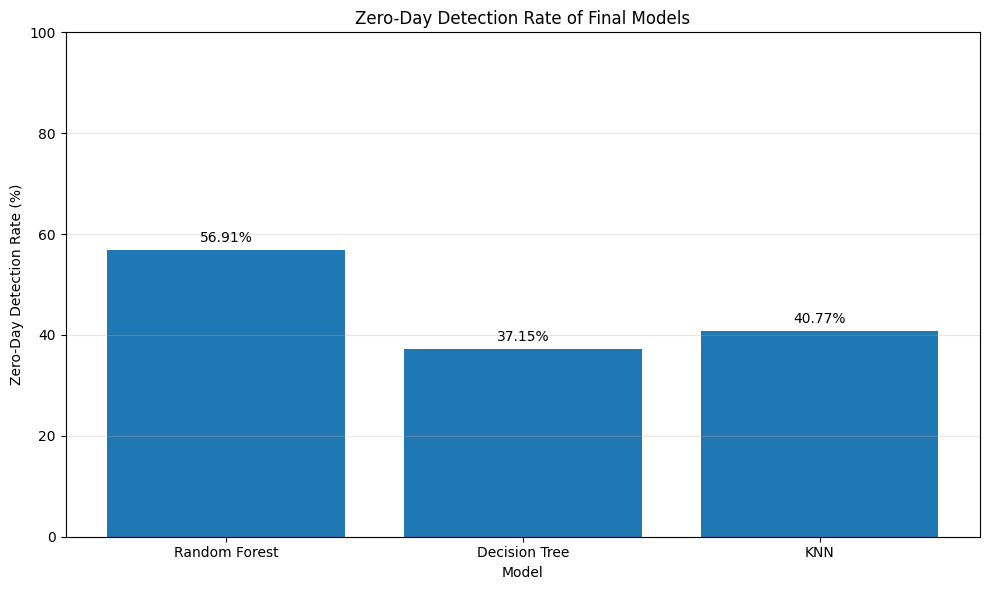

In [40]:
# ============================================
# Final Visualization 1
# Zero-Day Detection Rate Comparison
# ============================================

final_zero_day_results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Decision Tree",
        "KNN"
    ],
    "Zero-Day Detection (%)": [
        rf_zero_day_detection,
        dt_zero_day_detection,
        40.77
    ]
})

plt.figure(figsize=(10, 6))

bars = plt.bar(
    final_zero_day_results["Model"],
    final_zero_day_results["Zero-Day Detection (%)"]
)

plt.ylabel("Zero-Day Detection Rate (%)")
plt.xlabel("Model")
plt.title("Zero-Day Detection Rate of Final Models")
plt.ylim(0, 100)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.2f}%",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

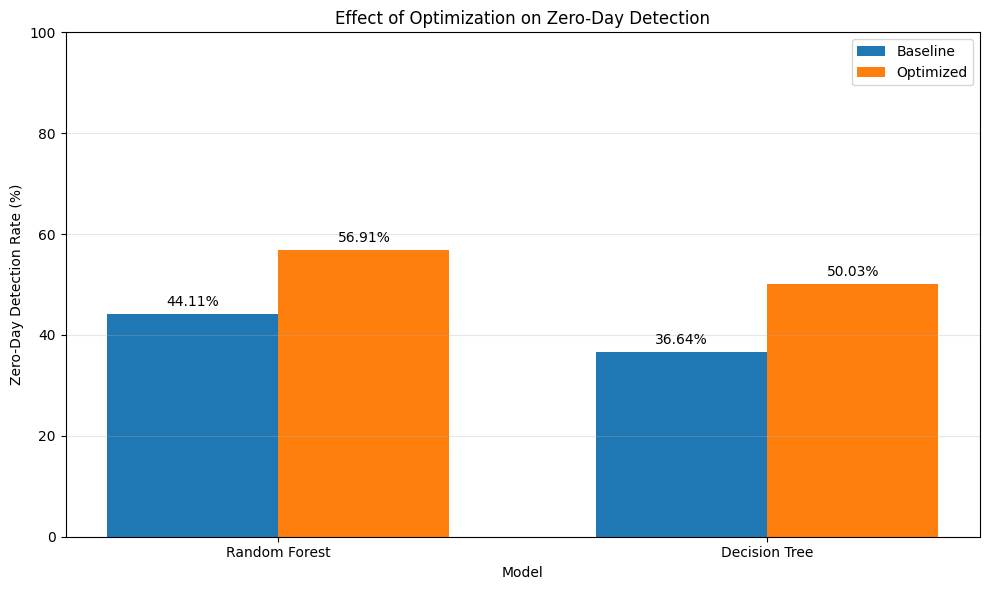

In [41]:
# ============================================
# Final Visualization 2
# Before vs After Optimization
# ============================================

optimization_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Decision Tree"
    ],
    "Baseline": [
        44.11,
        36.64
    ],
    "Optimized": [
        56.91,
        50.03
    ]
})

x = np.arange(len(optimization_comparison))
width = 0.35

plt.figure(figsize=(10, 6))

bars1 = plt.bar(
    x - width / 2,
    optimization_comparison["Baseline"],
    width,
    label="Baseline"
)

bars2 = plt.bar(
    x + width / 2,
    optimization_comparison["Optimized"],
    width,
    label="Optimized"
)

plt.ylabel("Zero-Day Detection Rate (%)")
plt.xlabel("Model")
plt.title("Effect of Optimization on Zero-Day Detection")
plt.xticks(x, optimization_comparison["Model"])
plt.ylim(0, 100)
plt.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f"{height:.2f}%",
            ha="center",
            va="bottom"
        )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

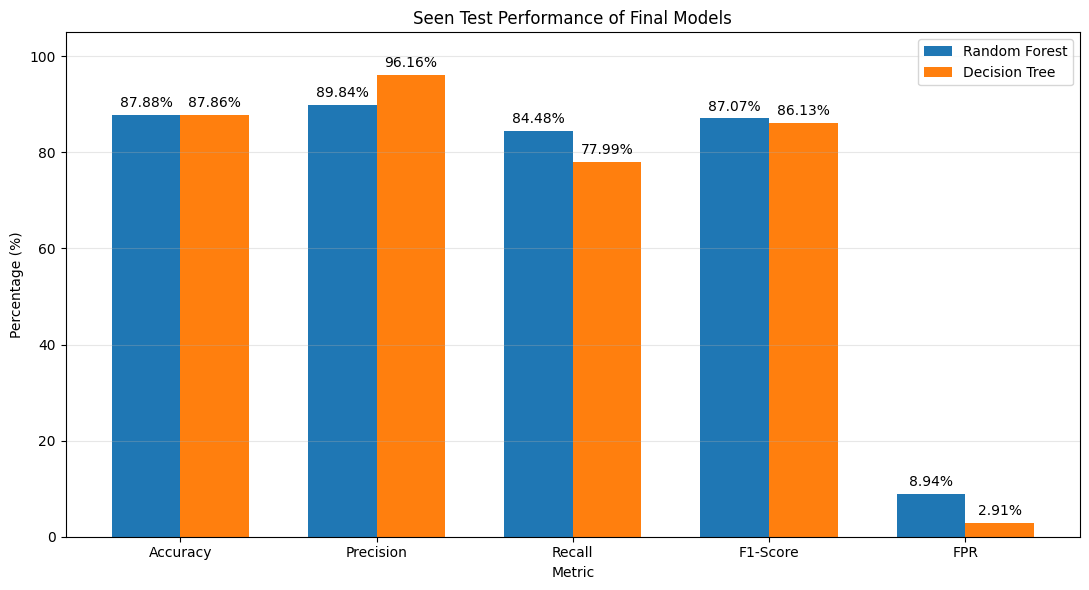

In [42]:
# ============================================
# Final Visualization 3
# Seen Test Performance Comparison
# ============================================

seen_test_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "FPR"
    ],
    "Random Forest": [
    seen_accuracy,
    seen_precision,
    seen_recall,
    seen_f1,
    seen_fpr
    ],
    "Decision Tree": [
        dt_seen_accuracy,
        dt_seen_precision,
        dt_seen_recall,
        dt_seen_f1,
        dt_seen_fpr
    ]
})

x = np.arange(len(seen_test_comparison))
width = 0.35

plt.figure(figsize=(11, 6))

bars1 = plt.bar(
    x - width / 2,
    seen_test_comparison["Random Forest"] * 100,
    width,
    label="Random Forest"
)

bars2 = plt.bar(
    x + width / 2,
    seen_test_comparison["Decision Tree"] * 100,
    width,
    label="Decision Tree"
)

plt.ylabel("Percentage (%)")
plt.xlabel("Metric")
plt.title("Seen Test Performance of Final Models")
plt.xticks(x, seen_test_comparison["Metric"])
plt.ylim(0, 105)
plt.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f"{height:.2f}%",
            ha="center",
            va="bottom"
        )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

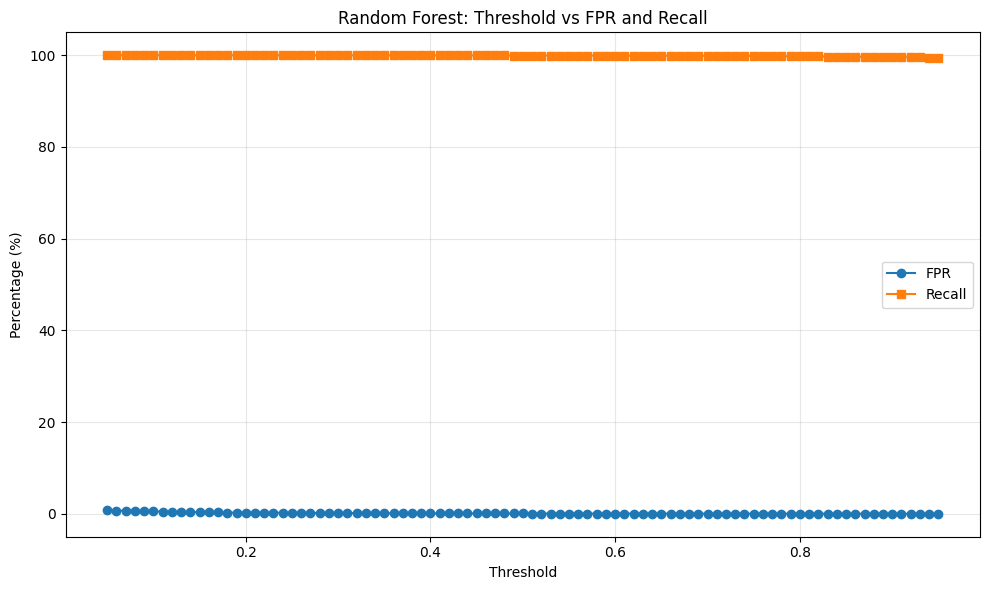

In [43]:
# ============================================
# Final Visualization 4
# Random Forest - Threshold Analysis
# ============================================

rf_threshold_plot = rf_threshold_results.copy()

plt.figure(figsize=(10, 6))

plt.plot(
    rf_threshold_plot["Threshold"],
    rf_threshold_plot["FPR"] * 100,
    marker="o",
    label="FPR"
)

plt.plot(
    rf_threshold_plot["Threshold"],
    rf_threshold_plot["Recall"] * 100,
    marker="s",
    label="Recall"
)

plt.xlabel("Threshold")
plt.ylabel("Percentage (%)")
plt.title("Random Forest: Threshold vs FPR and Recall")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [44]:
baseline_zero_day = pd.DataFrame({

    "Model": [
        "Decision Tree",
        "Random Forest",
        "KNN",
        "Linear SVM",
        "Logistic Regression"
    ],

    "Default Threshold Zero-Day (%)": [
        36.64,
        44.11,
        40.77,
        37.01,
        40.91
    ]
})

In [45]:
threshold_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Decision Tree"
    ],
    "Default Threshold Zero-Day (%)": [
        44.11,
        36.64
    ],
    "Optimized Zero-Day (%)": [
        56.91,
        50.03
    ]
})

threshold_comparison["Improvement (pp)"] = (
    threshold_comparison["Optimized Zero-Day (%)"]
    - threshold_comparison["Default Threshold Zero-Day (%)"]
)

threshold_comparison

,Model,Default Threshold Zero-Day (%),Optimized Zero-Day (%),Improvement (pp)
0,Random Forest,44.11,56.91,12.80
1,Decision Tree,36.64,50.03,13.39


In [46]:
import os
import joblib

models_path = "../models"
os.makedirs(models_path, exist_ok=True)

joblib.dump(rf, f"{models_path}/random_forest_optimized.pkl")
joblib.dump(dt_regularized, f"{models_path}/decision_tree_regularized.pkl")
joblib.dump(knn, "../models/knn_baseline.pkl")
joblib.dump(svm, "../models/linear_svm_baseline.pkl")
joblib.dump(lr, "../models/logistic_regression_baseline.pkl")

thresholds = {
    "random_forest": selected_threshold,
    "decision_tree": dt_reg_threshold
}

joblib.dump(
    thresholds,
    f"{models_path}/supervised_thresholds.pkl"
)

print("Supervised models saved successfully.")

Supervised models saved successfully.
